In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt
import joblib

In [ ]:
train_dir = "seg_train"
test_dir = "seg_test"

IMG_SIZE = 160
BATCH_SIZE = 16
EPOCHS_HEAD = 10
EPOCHS_FINE = 10

In [3]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    zoom_range=0.15,
    horizontal_flip=True,
    width_shift_range=0.1,
    height_shift_range=0.1,
    validation_split=0.2
)

test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

In [4]:
train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 11230 images belonging to 6 classes.
Found 2804 images belonging to 6 classes.
Found 3000 images belonging to 6 classes.


In [5]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

for layer in base_model.layers:
    layer.trainable = False

In [ ]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(train_data.num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

loss_fn = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1)

model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss=loss_fn,
    metrics=['accuracy']
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,592,582 (9.89 MB)

 Trainable params: 332,038 (1.27 MB)

 Non-trainable params: 2,260,544 (8.62 MB)

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

In [24]:
history_head = model.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS_HEAD,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/10
702/702 ━━━━━━━━━━━━━━━━━━━━ 255s 356ms/step - accuracy: 0.8029 - loss: 1.0166 - val_accuracy: 0.8841 - val_loss: 0.7297 - learning_rate: 0.0010
Epoch 2/10
702/702 ━━━━━━━━━━━━━━━━━━━━ 164s 233ms/step - accuracy: 0.8671 - loss: 0.7573 - val_accuracy: 0.8955 - val_loss: 0.6758 - learning_rate: 0.0010
Epoch 3/10
702/702 ━━━━━━━━━━━━━━━━━━━━ 161s 230ms/step - accuracy: 0.8808 - loss: 0.7214 - val_accuracy: 0.9055 - val_loss: 0.6627 - learning_rate: 0.0010
Epoch 4/10
702/702 ━━━━━━━━━━━━━━━━━━━━ 169s 241ms/step - accuracy: 0.8865 - loss: 0.7060 - val_accuracy: 0.9119 - val_loss: 0.6584 - learning_rate: 0.0010
Epoch 5/10
702/702 ━━━━━━━━━━━━━━━━━━━━ 239s 341ms/step - accuracy: 0.8913 - loss: 0.7058 - val_accuracy: 0.8962 - val_loss: 0.6844 - learning_rate: 0.0010
Epoch 6/10
702/702 ━━━━━━━━━━━━━━━━━━━━ 259s 369ms/step - accuracy: 0.8865 - loss: 0.7052 - val_accuracy: 0.9069 - val_loss: 0.6570 - learning_rate: 0.0010
Epoch 7/10
702/702 ━━━━━━━━━━━━━━━━━━━━ 258s 368ms/step - accura

In [25]:
for layer in base_model.layers[-40:]:
    layer.trainable = True

model.compile(
    optimizer=Adam(learning_rate=5e-6),  # ลดจาก 1e-5 → กัน overfit
    loss=loss_fn,
    metrics=['accuracy']
)

In [26]:
history_fine = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/10
702/702 ━━━━━━━━━━━━━━━━━━━━ 314s 428ms/step - accuracy: 0.8563 - loss: 0.7874 - val_accuracy: 0.9005 - val_loss: 0.7757 - learning_rate: 5.0000e-06
Epoch 2/10
702/702 ━━━━━━━━━━━━━━━━━━━━ 0s 340ms/step - accuracy: 0.8756 - loss: 0.7278
Epoch 2: ReduceLROnPlateau reducing learning rate to 1.4999999621068127e-06.
702/702 ━━━━━━━━━━━━━━━━━━━━ 275s 391ms/step - accuracy: 0.8801 - loss: 0.7236 - val_accuracy: 0.9133 - val_loss: 0.6956 - learning_rate: 5.0000e-06
Epoch 3/10
702/702 ━━━━━━━━━━━━━━━━━━━━ 295s 421ms/step - accuracy: 0.8860 - loss: 0.7039 - val_accuracy: 0.9101 - val_loss: 0.6717 - learning_rate: 1.5000e-06


In [27]:
test_loss, test_acc = model.evaluate(test_data)
print("Test Accuracy:", test_acc)

188/188 ━━━━━━━━━━━━━━━━━━━━ 27s 144ms/step - accuracy: 0.9120 - loss: 0.7432
Test Accuracy: 0.9120000004768372


In [15]:
model.save("nn_intel_model.keras")
joblib.dump(train_data.class_indices, "nn_labels.pkl")

print("Model saved ✅")

Model saved ✅


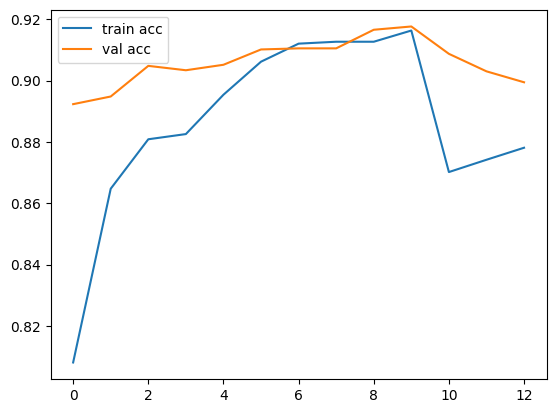

In [16]:
plt.plot(history_head.history['accuracy'] + history_fine.history['accuracy'], label='train acc')
plt.plot(history_head.history['val_accuracy'] + history_fine.history['val_accuracy'], label='val acc')
plt.legend()
plt.show()